Ridership at each stop visualizations

In [1]:
import pandas as pd
import numpy as np
import os

# import the busstate files
DATA_PATH = 'K:/AP/TTM/Data/transportation-planning/data/'
BUSSTATE_PATH = DATA_PATH + 'busstate-parsed/'
PATTERN_STOPS_PATH = DATA_PATH + 'pattern-stops/'

# read the busstate files
busstate_files = [BUSSTATE_PATH + f for f in os.listdir(BUSSTATE_PATH) if f.endswith('.csv')]
busstate_dfs = [pd.read_csv(f) for f in busstate_files]

# read the pattern-stops files
pattern_stops_files = [PATTERN_STOPS_PATH + f for f in os.listdir(PATTERN_STOPS_PATH) if f.endswith('.csv')]
pattern_stops_dfs = [pd.read_csv(f) for f in pattern_stops_files]

In [2]:
# split up busstates
oct25_busstate_df = busstate_dfs[0]
feb26_busstate_df = busstate_dfs[1]

# split up pattern-stops
oct25_pattern_stops_df = pattern_stops_dfs[0]
feb26_pattern_stops_df = pattern_stops_dfs[1]

# import stop inventory
stop_inventory = pd.read_csv(DATA_PATH + 'stop_inventory.csv')

In [3]:
oct25_busstate_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1129586 entries, 0 to 1129585
Data columns (total 23 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   DATE                    1129586 non-null  str    
 1   BUS_ID                  1129586 non-null  int64  
 2   RUN_ID                  1123592 non-null  float64
 3   DEST_SIGN_ROUTE_TEXT    1129570 non-null  str    
 4   BLOCK_ID                1128291 non-null  float64
 5   TRIP_ID                 1121085 non-null  float64
 6   ROUTE_ID                1125001 non-null  str    
 7   STOP_SEQUENCE           1129586 non-null  int64  
 8   LATITUDE                1129586 non-null  float64
 9   LONGITUDE               1129586 non-null  float64
 10  HEADING                 1129586 non-null  int64  
 11  OPERATOR_ID             1112076 non-null  float64
 12  ODOMETER_DISTANCE       1129586 non-null  int64  
 13  TIMEPOINT_ID            125674 non-null   str    
 14  EVENT_TYPE   

In [4]:
# Clever Devices APC business rules that can be evaluated from the busstate files.
MAX_STOP_ACTIVITY = 90
MIN_LOAD = -5
MAX_BLOCK_DIFFERENCE = 0.30
MAX_UNKNOWN_STOP_SHARE = 0.20
MAX_LOAD_CARRYOVER = 90
STOP_MATCH_RADIUS_DEGREES = 350 / 364000

# Populate this set when the agency's APC-equipped vehicle list is available.
APC_VEHICLE_IDS = None


def _nearest_known_stop_mask(data, stop_inventory, radius=STOP_MATCH_RADIUS_DEGREES):
    """Return whether each busstate coordinate is within the configured stop radius."""
    coordinates = data[['LATITUDE', 'LONGITUDE']].to_numpy(dtype=float)
    stops = stop_inventory[['LAT', 'LONG']].to_numpy(dtype=float)
    known = np.zeros(len(data), dtype=bool)
    for start in range(0, len(data), 100_000):
        stop_slice = coordinates[start:start + 100_000]
        valid_coordinates = np.isfinite(stop_slice).all(axis=1)
        distances = np.sqrt(
            (stop_slice[:, None, 0] - stops[None, :, 0]) ** 2
            + (stop_slice[:, None, 1] - stops[None, :, 1]) ** 2
        )
        known[start:start + len(stop_slice)] = (
            valid_coordinates & (distances.min(axis=1) <= radius)
        )
    return known


def _append_reason(reasons, mask, reason):
    """Append a discard reason without replacing an earlier reason."""
    reasons.loc[mask] = reasons.loc[mask].where(
        reasons.loc[mask].eq(''),
        reasons.loc[mask] + '; ',
    ) + reason


def apply_apc_business_rules(
    data,
    stop_inventory,
    enforce_unknown_stop_rule=False,
):
    """Validate and adjust busstate records using the checked APC rules.

    The raw files do not contain a stop ID or pattern stop sequence. Therefore,
    coordinate-based unknown-stop enforcement is diagnostic by default and can
    only discard trips when explicitly enabled.
    """
    working = data.copy()
    working['DATE_PARSED'] = pd.to_datetime(working['DATE'], errors='coerce')
    working['ROUTE_ID'] = working['ROUTE_ID'].astype('string').str.strip()
    working['TRIP_KEY_VALID'] = working[
        ['DATE', 'RUN_ID', 'ROUTE_ID', 'TRIP_ID']
    ].notna().all(axis=1)
    working['RULE_REASON'] = pd.Series('', index=working.index, dtype='string')
    _append_reason(working['RULE_REASON'], working['DATE_PARSED'].isna(), 'invalid date')
    _append_reason(working['RULE_REASON'], ~working['TRIP_KEY_VALID'], 'invalid trip key')
    _append_reason(working['RULE_REASON'], working['BUS_ID'].isna(), 'null vehicle number')
    _append_reason(working['RULE_REASON'], working['BOARDINGS'].gt(MAX_STOP_ACTIVITY), 'boardings over 90')
    _append_reason(working['RULE_REASON'], working['ALIGHTINGS'].gt(MAX_STOP_ACTIVITY), 'alightings over 90')
    _append_reason(working['RULE_REASON'], working['PASSENGER_LOAD'].lt(MIN_LOAD), 'minimum load below -5')
    if APC_VEHICLE_IDS is not None:
        _append_reason(working['RULE_REASON'], ~working['BUS_ID'].isin(APC_VEHICLE_IDS), 'vehicle without APC equipment')

    # Keep this diagnostic even though enforcement is opt-in for the raw schema.
    working['KNOWN_STOP'] = _nearest_known_stop_mask(working, stop_inventory)
    trip_columns = ['DATE', 'RUN_ID', 'ROUTE_ID', 'TRIP_ID']
    trip_stats = working.groupby(trip_columns, dropna=False).agg(
        UNKNOWN_STOP_SHARE=('KNOWN_STOP', lambda values: 1 - values.mean()),
    )
    invalid_unknown_trips = trip_stats.index[trip_stats['UNKNOWN_STOP_SHARE'].gt(MAX_UNKNOWN_STOP_SHARE)]
    unknown_trip_mask = working.set_index(trip_columns).index.isin(invalid_unknown_trips)
    if enforce_unknown_stop_rule:
        _append_reason(working['RULE_REASON'], unknown_trip_mask, 'unknown activity stops over 20%')

    invalid_trip_index = working.loc[working['RULE_REASON'].ne('')].set_index(trip_columns).index
    invalid_trip_mask = working.set_index(trip_columns).index.isin(invalid_trip_index)
    _append_reason(working['RULE_REASON'], invalid_trip_mask, 'trip discarded')

    retained = working.loc[working['RULE_REASON'].eq('')].copy()
    discarded = working.loc[working['RULE_REASON'].ne('')].copy()

    block_columns = ['DATE', 'BLOCK_ID']
    block_totals = retained.groupby(block_columns, dropna=False).agg(
        BLOCK_BOARDINGS=('BOARDINGS', 'sum'),
        BLOCK_ALIGHTINGS=('ALIGHTINGS', 'sum'),
    )
    block_max = block_totals[['BLOCK_BOARDINGS', 'BLOCK_ALIGHTINGS']].max(axis=1)
    block_difference = (
        block_totals['BLOCK_BOARDINGS'] - block_totals['BLOCK_ALIGHTINGS']
    ).abs()
    invalid_blocks = block_totals.index[
        block_totals.index.get_level_values('BLOCK_ID').isna()
        | (~block_max.eq(0) & block_difference.ge(MAX_BLOCK_DIFFERENCE * block_max))
    ]
    invalid_block_mask = retained.set_index(block_columns).index.isin(invalid_blocks)
    retained.loc[invalid_block_mask, 'RULE_REASON'] = np.where(
        retained.loc[invalid_block_mask, 'BLOCK_ID'].isna(),
        'missing valid signup',
        'block boardings/alightings differ by 30% or more',
    )
    discarded = pd.concat([discarded, retained.loc[invalid_block_mask]], ignore_index=True)
    retained = retained.loc[~invalid_block_mask].copy()

    retained = retained.sort_values(
        ['BUS_ID', 'DATE_PARSED', 'BLOCK_ID', 'TRIP_ID', 'STOP_SEQUENCE', 'EVENT_TIME']
    ).copy()
    retained['RAW_BOARDINGS'] = retained['BOARDINGS']
    retained['RAW_ALIGHTINGS'] = retained['ALIGHTINGS']
    retained['RAW_PASSENGER_LOAD'] = retained['PASSENGER_LOAD']
    retained['ADJUSTED_BOARDINGS'] = retained['BOARDINGS'].astype(float)
    retained['ADJUSTED_ALIGHTINGS'] = retained['ALIGHTINGS'].astype(float)
    retained['ADJUSTED_LOAD'] = retained['PASSENGER_LOAD'].astype(float)

    for _, block in retained.groupby(block_columns, sort=False, dropna=False):
        block_index = block.index
        first_index = block_index[0]
        last_index = block_index[-1]
        retained.loc[first_index, 'ADJUSTED_ALIGHTINGS'] = 0
        retained.loc[first_index, 'ADJUSTED_LOAD'] = retained.loc[first_index, 'ADJUSTED_BOARDINGS']
        running_load = retained.loc[first_index, 'ADJUSTED_LOAD']
        for row_index in block_index[1:-1]:
            running_load += (
                retained.loc[row_index, 'ADJUSTED_BOARDINGS']
                - retained.loc[row_index, 'ADJUSTED_ALIGHTINGS']
            )
            retained.loc[row_index, 'ADJUSTED_LOAD'] = running_load
        if len(block_index) > 1:
            running_load += retained.loc[last_index, 'ADJUSTED_BOARDINGS']
            retained.loc[last_index, 'ADJUSTED_BOARDINGS'] = 0
            retained.loc[last_index, 'ADJUSTED_ALIGHTINGS'] = max(running_load, 0)
            retained.loc[last_index, 'ADJUSTED_LOAD'] = 0

    retained['LOAD_CARRYOVER'] = (
        retained.groupby(['BUS_ID', 'DATE_PARSED'])['ADJUSTED_LOAD']
        .shift(1)
        .fillna(0)
        .clip(lower=0, upper=MAX_LOAD_CARRYOVER)
    )
    retained['TRIP_KEY'] = (
        retained['DATE'].astype('string') + '|' +
        retained['RUN_ID'].astype('string') + '|' +
        retained['ROUTE_ID'] + '|' +
        retained['TRIP_ID'].astype('string')
    )
    return retained, discarded


all_busstate_df = pd.concat(busstate_dfs, ignore_index=True)
busstate_business_rules_df, discarded_busstate_df = apply_apc_business_rules(
    all_busstate_df,
    stop_inventory,
)

print(f'Input records: {len(all_busstate_df):,}')
print(f'Retained records: {len(busstate_business_rules_df):,}')
print(f'Discarded records: {len(discarded_busstate_df):,}')
print(f'Retained trips: {busstate_business_rules_df["TRIP_KEY"].nunique():,}')
print(discarded_busstate_df['RULE_REASON'].value_counts().head())

Input records: 2,126,858
Retained records: 2,068,201
Discarded records: 58,657
Retained trips: 106,596
RULE_REASON
block boardings/alightings differ by 30% or more    56372
missing valid signup                                 2285
Name: count, dtype: int64[pyarrow]


In [5]:
october_business_rules_df, october_discarded_df = apply_apc_business_rules(
    oct25_busstate_df,
    stop_inventory,
)

october_business_rules_df['BOARDINGS'].sum()

np.int64(445266)

In [6]:
october_business_rules_df['BOARDINGS'].sum()

np.int64(445266)

In [7]:
oct25_busstate_df = october_business_rules_df.copy()

OCtober 2025 total boardings per ridecheck `430,139`

In [8]:
oct25_busstate_df['BOARDINGS'].sum()

np.int64(445266)

In [9]:
oct25_busstate_df['ALIGHTINGS'].sum()

np.int64(443719)

In [10]:
stop_inventory.shape

(67, 6)

In [11]:
def build_stops_df():
    '''
    Build stops dataframe by merging static pattern stops and stop inventory files. Anytime that stops change, this will need to be re run after the csv files are updated.
    This contains every stop for CABS.

    Parameters:
        None
    Returns:
        stops_df (pd.DataFrame): dataframe with stop id, stop name, and lat/lon coordinates for all stops in the pattern stops file
    '''
    pattern_stop_file_name = '2025082420251018Sch-PatternStops_oct2025'

    pattern_stops_path = f"K:/AP/TTM/Data/transportation-planning/data/pattern-stops/{pattern_stop_file_name}.csv"
    stop_inventory_path = "K:/AP/TTM/Data/transportation-planning/data/stop_inventory.csv"

    # read in static stop files
    pattern_stops = pd.read_csv(pattern_stops_path, header = None) # no header
    stop_inventory = pd.read_csv(stop_inventory_path)

    print(pattern_stops.shape)
    print(stop_inventory.shape)

    # only need cols 0 and 9 and can drop any dups
    pattern_stops = pattern_stops.iloc[:, [0, 9]].drop_duplicates()
    pattern_stops.columns = ["ROUTE", "STOP_ID"] # rename cols for merge

    # Merge pattern stops and stop inventory on stop id - left merge 
    stops_df = pattern_stops.merge(stop_inventory, how = "left", on = "STOP_ID")
    
    print(stops_df.shape)

    return stops_df

In [12]:
stops_df = build_stops_df()
print(stops_df.shape)
stops_df.head()

(230, 46)
(67, 6)
(96, 7)
(96, 7)


,ROUTE,STOP_ID,STOP_NAME,TIMEPOINT_NAME,LONG,LAT,HEADING
0,BE,75,BUCKEYE LOT LOOP,BLOOP,-83.030646,40.015933,180.0
1,BE,20,MID WEST CAMPUS (EB),AGEB,-83.026541,40.004251,90.0
2,BE,21,ST. JOHN EAST BOUND,NaN,-83.020744,40.004048,90.0
3,BE,57,KNOWLTON HALL,KNWTN,-83.016142,40.003979,90.0
4,BE,58,FONTANA LAB,NaN,-83.013197,40.003839,90.0


In [13]:
stops_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ROUTE           96 non-null     str    
 1   STOP_ID         96 non-null     int64  
 2   STOP_NAME       96 non-null     str    
 3   TIMEPOINT_NAME  48 non-null     str    
 4   LONG            96 non-null     float64
 5   LAT             96 non-null     float64
 6   HEADING         88 non-null     float64
dtypes: float64(3), int64(1), str(3)
memory usage: 7.3 KB


In [14]:
# removing the route parameter, for this analysis, only boardings and alightings matter, overlapping stops on different routes should not impact the results here
def which_stop(lat, lon, stops_df = build_stops_df(), max_distance = 0.0005):
    '''s
    Determine the closest stop to a given latitude and longitude. Med center route is default, but can be updated to other routes as needed. 
    NOTE: stops_df must be a global variable for this function to work, so build_stops_df() must be run before this function is called.

    Args:
        lat (float): The latitude of the point of interest.
        lon (float): The longitude of the point of interest.
        stops_df (pd.DataFrame): DataFrame containing stop information created from build_stops_df() function
        route (str): The route to filter stops by. Default is "MC" for medical center. Based on ROUTE col in stops DataFrame. Potentially important in future for overlapping stops.
        max_distance (float): The maximum distance to consider for a stop. Default is 0.0005 per legacy R code. approximately 150ish feet

    Returns:
        int: The STOP_ID of the closest stop within approximately 150 feet, or None if no stops are within the specified distance.
    '''
    # # subset the stops to route of interest
    # route_stops = stops_df[stops_df['ROUTE'] == route]

    distance_lon = stops_df['LONG'].values - lon
    distance_lat = stops_df['LAT'].values - lat

    # calculate the distance to each stop
    distances = np.sqrt(distance_lon**2 + distance_lat**2)

    mask = distances < max_distance
    # lowest distance should be the closest stop now. - each stop is at minimum approx 430ft apart so margin of 150 should be fine for MC route.
    selected_stop = stops_df[mask]

    # if no stops within alloted distance, return None
    if not np.any(mask):
        return None

    # return the closest stop within the allotted distance
    return int(stops_df.loc[mask, 'STOP_ID'].iloc[0])

(230, 46)
(67, 6)
(96, 7)


In [15]:
# filter and run the which_stop function for a given set of coordinates on the october data
filtered_oct_df = oct25_busstate_df.copy()  # assuming october_data is the DataFrame containing the October data
# sort by date and event time
filtered_oct_df = filtered_oct_df.sort_values(by=['DATE', 'EVENT_TIME'])
# apply the which_stop function to each row to determine the closest stop
filtered_oct_df['STOP_ID'] = filtered_oct_df.apply(lambda row: which_stop(row['LATITUDE'], row['LONGITUDE']), axis=1)

In [16]:
filtered_oct_df.describe().T

,count,mean,min,25%,50%,75%,max,std
BUS_ID,1107781.0,2026.047642,1301.0,1801.0,2003.0,2302.0,2503.0,341.558491
RUN_ID,1104304.0,1391.437387,1001.0,1301.0,1405.0,1504.0,7000.0,315.850897
BLOCK_ID,1107781.0,23676264.46413,23672305.0,23675302.0,23676502.0,23677202.0,23684201.0,1493.095056
TRIP_ID,1102555.0,1971575.956607,1020.0,942020.0,1959050.0,2970020.0,4141051.0,1179495.24548
STOP_SEQUENCE,1107781.0,3.515823,-1.0,1.0,3.0,5.0,16.0,3.587117
LATITUDE,1107781.0,40.001936,0.0,39.997997,40.001812,40.004055,40.017254,0.076176
LONGITUDE,1107781.0,-83.022585,-83.04348,-83.033363,-83.024529,-83.013252,0.0,0.158326
HEADING,1107781.0,182.924016,0.0,92.0,182.0,274.0,360.0,111.989703
OPERATOR_ID,1095258.0,781.997577,7.0,739.0,761.0,786.0,7310.0,256.01578
ODOMETER_DISTANCE,1107781.0,329784.922066,0.0,128854.0,290556.0,501275.0,1279225.0,232919.124659


In [17]:
# left merge the names of the stops with the filtered October DataFrame
filtered_oct_df = filtered_oct_df.merge(stops_df[['STOP_ID', 'STOP_NAME']], on='STOP_ID', how='left')

In [18]:
filtered_oct_df['STOP_NAME'].value_counts()

STOP_NAME
JOHN HERRICK LOOP       316036
OHIO UNION (NB)         146632
MID WEST CAMPUS (EB)     91440
ARPS HALL                71504
MOUNT HALL LOOP          57507
                         ...  
MID WEST CAMPUS (WB)       776
ST. JOHN ARENA (WB)        393
11TH & WORTHINGTON         302
STOP3                      294
OHIO UNION (SB)            171
Name: count, Length: 61, dtype: int64

In [19]:
service_annex_testcase = filtered_oct_df[filtered_oct_df['STOP_ID'] == 103]
print(f'Boardings at Service Annex: {service_annex_testcase["BOARDINGS"].describe().T}')
print(f'Alightings at Service Annex: {service_annex_testcase["ALIGHTINGS"].describe().T}')

Boardings at Service Annex: count    2723.000000
mean        0.130738
std         0.419692
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         3.000000
Name: BOARDINGS, dtype: float64
Alightings at Service Annex: count    2723.000000
mean        0.154976
std         0.494124
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         5.000000
Name: ALIGHTINGS, dtype: float64


In [20]:
# convert to dateimte
filtered_oct_df['EVENT_TIME'] = pd.to_datetime(filtered_oct_df['EVENT_TIME'], format = "%H:%M:%S")
filtered_oct_df['DEPARTURE_TIME'] = pd.to_datetime(filtered_oct_df['DEPARTURE_TIME'], format = "%H:%M:%S")
filtered_oct_df['ENTER_STOP_WINDOW_TIME'] = pd.to_datetime(filtered_oct_df['ENTER_STOP_WINDOW_TIME'], format = "%H:%M:%S")
filtered_oct_df['EXIT_STOP_WINDOW_TIME'] = pd.to_datetime(filtered_oct_df['EXIT_STOP_WINDOW_TIME'], format = "%H:%M:%S")

In [21]:
count = (
    (filtered_oct_df['STOP_ID'] != filtered_oct_df['STOP_ID'].shift(1)) |
    (filtered_oct_df['BUS_ID'] != filtered_oct_df['BUS_ID'].shift(1)) |
    ((filtered_oct_df['EVENT_TIME'] - filtered_oct_df['EVENT_TIME'].shift(1)).dt.total_seconds() >= 3600) 
    # this should create a new event if more than an hour has passed since the last event
)

# take cumsum of count to assign 
filtered_oct_df['COUNT'] = count.cumsum()

# consolidate df
consolidated_busstate_df = filtered_oct_df.groupby(['BUS_ID', 'DATE', 'COUNT', 'STOP_ID', 'STOP_NAME', 'RUN_ID'], as_index = False).agg(
    BOARDINGS = ('BOARDINGS', 'max'), # this WAS max
    ALIGHTINGS = ('ALIGHTINGS', 'max'), # this WAS max
    LOAD = ('PASSENGER_LOAD', 'max'),
    EARLY_EVENT=("EVENT_TIME", "min"),
    LATE_EVENT=("EVENT_TIME", "max"),
    DEPARTURE_TIME=("DEPARTURE_TIME", "max"),
    ENTER_STOP=("ENTER_STOP_WINDOW_TIME", "min"),
    EXIT_STOP=("EXIT_STOP_WINDOW_TIME", "max"),
    RUN_ID = ("RUN_ID", "last"),
    STOP_NAME = ("STOP_NAME", "last"),
    DEST=("DEST_SIGN_ROUTE_TEXT", "last"),
)

print(consolidated_busstate_df.shape)
consolidated_busstate_df.head()

(411556, 15)


,BUS_ID,DATE,COUNT,STOP_ID,BOARDINGS,ALIGHTINGS,LOAD,EARLY_EVENT,LATE_EVENT,DEPARTURE_TIME,ENTER_STOP,EXIT_STOP,RUN_ID,STOP_NAME,DEST
0,1301,2025-10-02,43123,403.0,10,0,10,1900-01-01 06:06:41,1900-01-01 06:06:41,1900-01-01 06:07:20,1900-01-01 06:03:46,1900-01-01 06:07:32,1509.0,CARMACK 2,MC
1,1301,2025-10-02,43175,404.0,4,0,14,1900-01-01 06:08:48,1900-01-01 06:08:48,1900-01-01 06:09:16,1900-01-01 06:08:38,1900-01-01 06:09:28,1509.0,CARMACK 3,MC
2,1301,2025-10-02,43227,502.0,0,0,0,1900-01-01 06:10:51,1900-01-01 06:10:51,NaT,NaT,NaT,1509.0,(FS) PS (IN),MC
3,1301,2025-10-02,43360,405.0,0,0,0,1900-01-01 06:15:05,1900-01-01 06:15:05,1900-01-01 06:15:22,NaT,NaT,1509.0,JOHN HERRICK LOOP,MC
4,1301,2025-10-02,43365,405.0,0,14,0,1900-01-01 06:15:16,1900-01-01 06:15:16,1900-01-01 06:15:16,1900-01-01 06:15:11,1900-01-01 06:15:21,1509.0,JOHN HERRICK LOOP,MC


In [22]:
consolidated_busstate_df['STOP_NAME'].value_counts()

STOP_NAME
JOHN HERRICK LOOP       47442
CARMACK 2               29938
OHIO UNION (NB)         23794
MID WEST CAMPUS (EB)    21558
(FS) PS (OB)            18088
                        ...  
STOP3                     290
MID WEST CAMPUS (WB)      183
11TH & WORTHINGTON        151
ST. JOHN ARENA (WB)       131
OHIO UNION (SB)           104
Name: count, Length: 61, dtype: int64

In [23]:
# create summary statistics for boardings/alightings at each stop
stop_summary_stats = consolidated_busstate_df.groupby('STOP_NAME', as_index=False).agg(
    # BOARDINGS_MEAN=('BOARDINGS', 'mean'),
    BOARDINGS_SUM=('BOARDINGS', 'sum'),
    # ALIGHTINGS_MEAN=('ALIGHTINGS', 'mean'),
    ALIGHTINGS_SUM=('ALIGHTINGS', 'sum'),
)
# msort by total bordings
stop_summary_stats = stop_summary_stats.sort_values(by='BOARDINGS_SUM', ascending=False)

stop_summary_stats.head(50)

,STOP_NAME,BOARDINGS_SUM,ALIGHTINGS_SUM
31,JOHN HERRICK LOOP,83151,85407
39,OHIO UNION (NB),51184,33924
16,BUCKEYE LOT LOOP,26130,25553
19,CARMACK 3,24942,22781
18,CARMACK 2,23993,27134
36,MID WEST CAMPUS (EB),23520,24905
24,FONTANA LAB,23071,22764
35,MASON HALL,22583,16086
14,BLACKBURN HOUSE,22190,18975
20,CARMACK 5 + STOP 1,21612,23823


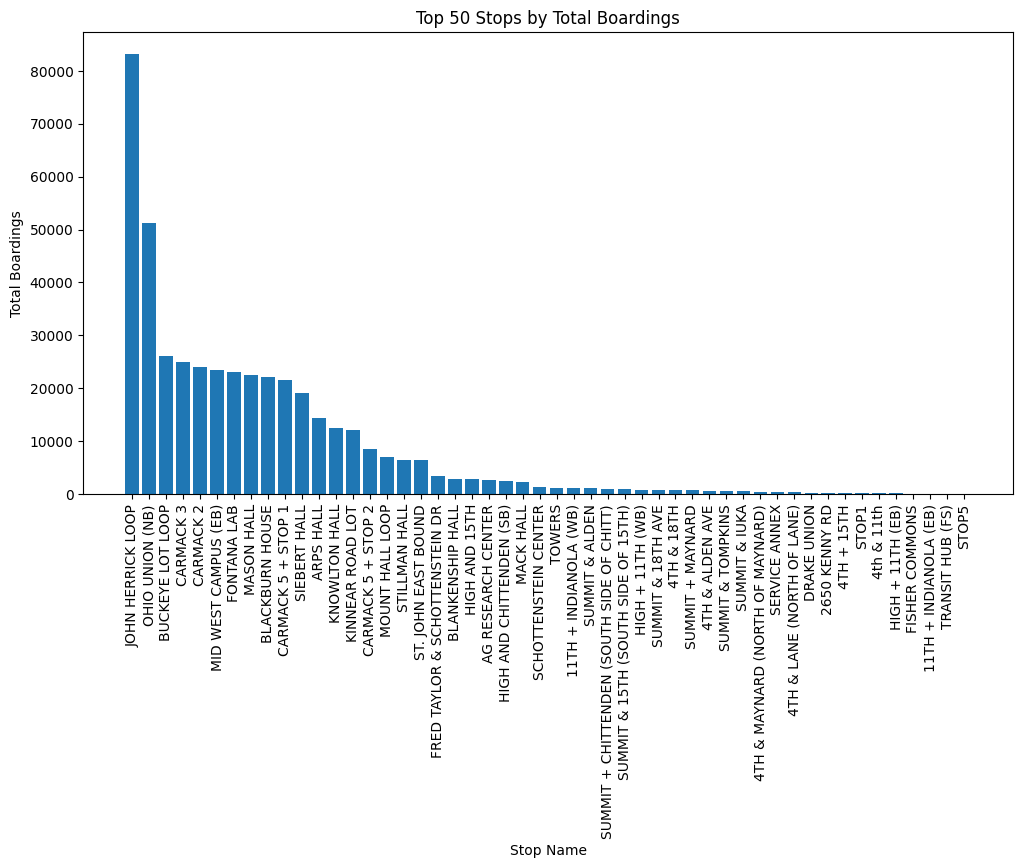

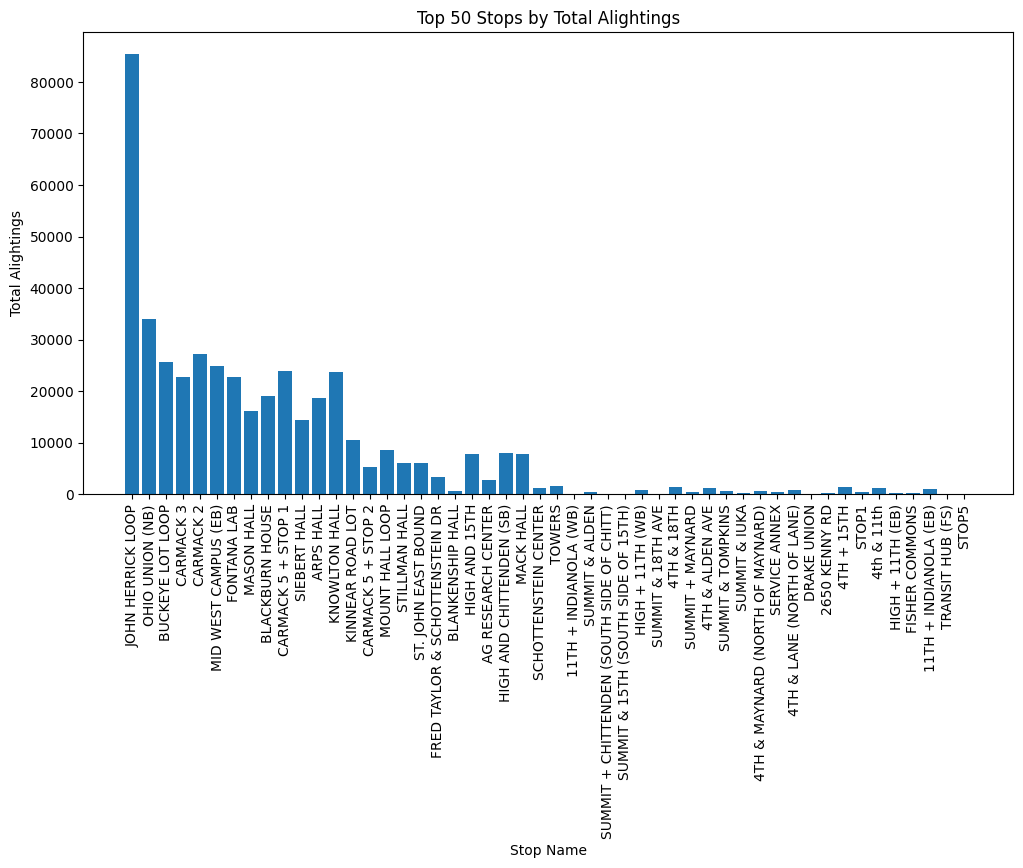

In [24]:
# plot top 50 stops by boardings
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
ax = plt.bar(stop_summary_stats['STOP_NAME'].head(50), stop_summary_stats['BOARDINGS_SUM'].head(50))

plt.xticks(rotation=90)
plt.xlabel('Stop Name')
plt.ylabel('Total Boardings')
plt.title('Top 50 Stops by Total Boardings')
plt.show()

# plot top 50 stops by alightings
plt.figure(figsize=(12, 6))
plt.bar(stop_summary_stats['STOP_NAME'].head(50), stop_summary_stats['ALIGHTINGS_SUM'].head(50))
plt.xticks(rotation=90)
plt.xlabel('Stop Name')
plt.ylabel('Total Alightings')
plt.title('Top 50 Stops by Total Alightings')
plt.show()

In [25]:
# remove MC routes to avoid the skewing here...
med_center_run_ids = [
    1501,
    1502,
    1503,
    1504,
    1505,
    1506,
    1507,
    1508,
    1509,
    1510,
    1511,
    1512,
    1513,
    1514,
]
cut_consolidated_busstate_df = consolidated_busstate_df[~consolidated_busstate_df['RUN_ID'].isin(med_center_run_ids)]

# recalculate stop summary stats after removing MC routes
stop_summary_stats = cut_consolidated_busstate_df.groupby('STOP_NAME', as_index=False).agg(
    BOARDINGS_SUM=('BOARDINGS', 'sum'),
    ALIGHTINGS_SUM=('ALIGHTINGS', 'sum'),
)
stop_summary_stats = stop_summary_stats.sort_values(by='BOARDINGS_SUM', ascending=False)
stop_summary_stats

,STOP_NAME,BOARDINGS_SUM,ALIGHTINGS_SUM
39,OHIO UNION (NB),51184,33924
16,BUCKEYE LOT LOOP,26130,25553
36,MID WEST CAMPUS (EB),23520,24905
24,FONTANA LAB,23071,22764
35,MASON HALL,22583,16086
...,...,...,...
40,OHIO UNION (SB),0,0
41,Outbound to Carmack,0,0
45,ST. JOHN ARENA (WB),0,0
49,STOP3,0,0


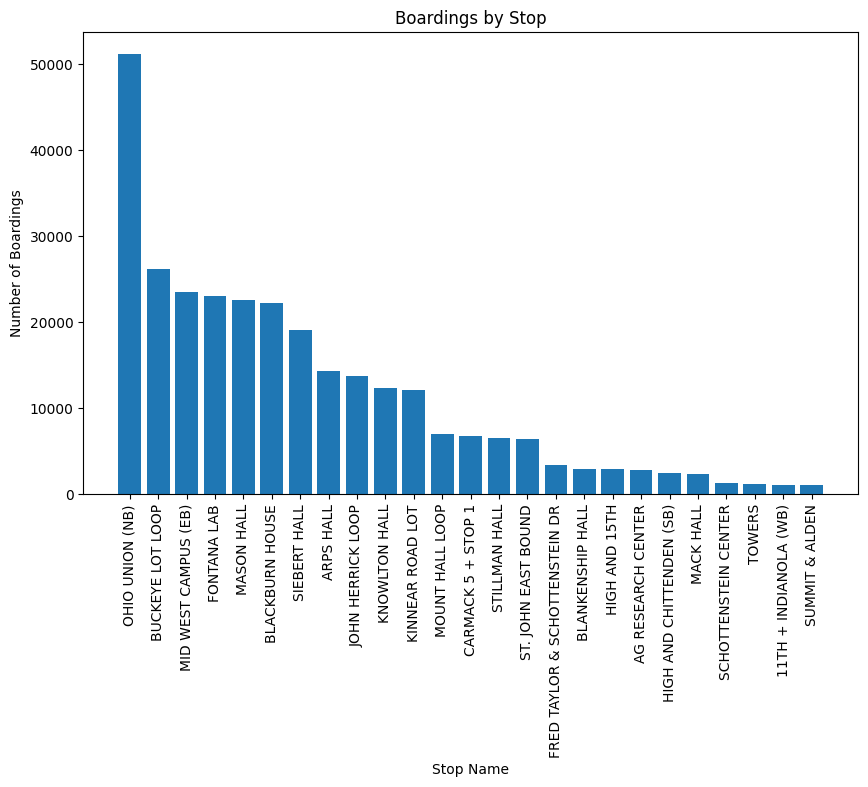

In [26]:
# plot the boardings 
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.bar(stop_summary_stats['STOP_NAME'].head(25), stop_summary_stats['BOARDINGS_SUM'].head(25))
plt.xticks(rotation=90)
plt.xlabel('Stop Name')
plt.ylabel('Number of Boardings')
plt.title('Boardings by Stop')
plt.show()

In [27]:
# Interactive geographic heatmap of October boardings by stop.
import folium
from branca.colormap import linear

stop_boarding_map = (
    consolidated_busstate_df
    .groupby('STOP_ID', as_index=False)
    .agg(BOARDINGS_SUM=('BOARDINGS', 'sum'))
    .merge(
        stop_inventory[['STOP_ID', 'STOP_NAME', 'LONG', 'LAT']],
        on='STOP_ID',
        how='left',
        validate='one_to_one',
    )
    .dropna(subset=['LONG', 'LAT'])
)

plot_data = stop_boarding_map.loc[
    stop_boarding_map['BOARDINGS_SUM'].gt(0)
].copy()

map_center = [plot_data['LAT'].mean(), plot_data['LONG'].mean()]
boarding_min = plot_data['BOARDINGS_SUM'].min()
boarding_max = plot_data['BOARDINGS_SUM'].max()
color_scale = linear.YlOrRd_09.scale(boarding_min, boarding_max)
color_scale.caption = 'Total October boardings'

boarding_map = folium.Map(
    location=map_center,
    zoom_start=13,
    tiles='OpenStreetMap',
    control_scale=True,
)

for _, stop in plot_data.iterrows():
    boarding_count = int(stop['BOARDINGS_SUM'])
    radius = 5 + 14 * (boarding_count / boarding_max) ** 0.5
    popup_html = (
        f"<strong>{stop['STOP_NAME']}</strong><br>"
        f"Stop ID: {int(stop['STOP_ID'])}<br>"
        f"Boardings: {boarding_count:,}"
    )
    folium.CircleMarker(
        location=[stop['LAT'], stop['LONG']],
        radius=radius,
        color='#7f0000',
        weight=1,
        fill=True,
        fill_color=color_scale(boarding_count),
        fill_opacity=0.8,
        tooltip=f"{stop['STOP_NAME']}: {boarding_count:,} boardings",
        popup=folium.Popup(popup_html, max_width=250),
    ).add_to(boarding_map)

color_scale.add_to(boarding_map)
boarding_map